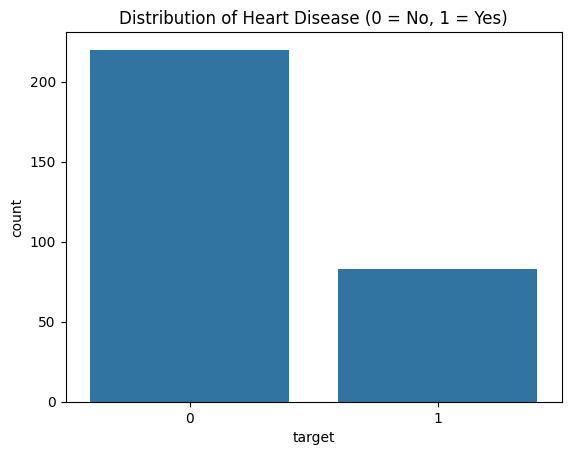

Accuracy Score: 0.85


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


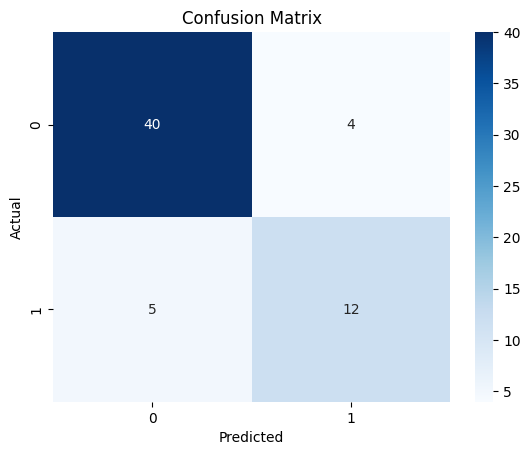

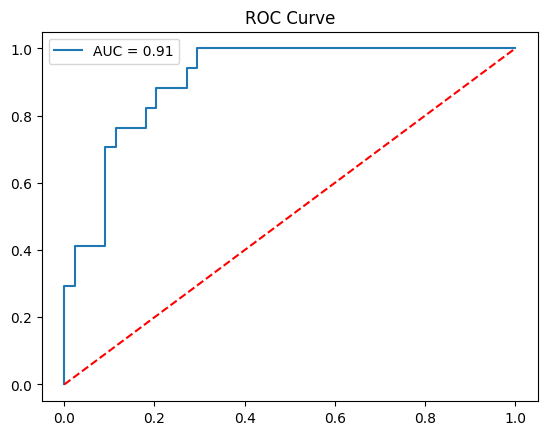

In [7]:
# import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# 1. Load Dataset (Using a common URL for the UCI Heart Disease dataset)
url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)

# 2. Cleaning & Basic EDA
# Checking for missing values (This specific dataset is usually clean)
df = df.dropna()

# Handle categorical features using one-hot encoding
df = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True)

# Visualizing the target distribution
sns.countplot(x='target', data=df)
plt.title("Distribution of Heart Disease (0 = No, 1 = Yes)")
plt.show()

# 3. Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Application (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title("ROC Curve")
plt.legend()
plt.show()